# Visualizing Differences Between LES and Nudging Simulations

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
from IPython.display import HTML

# Load difference data
u_dif = np.loadtxt('u_dif_100.csv', delimiter=',')
v_dif = np.loadtxt('v_dif_100.csv', delimiter=',')
mag_dif = np.sqrt(u_dif**2 + v_dif**2)

# Assume shape and grid
nt = 100
ny, nx = u_dif.shape
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

# Dummy temporal evolution for animation (extend to nt steps with noise)
mag_dif_t = np.stack([mag_dif + 0.01*np.random.randn(*mag_dif.shape)*np.sin(i/10) for i in range(nt)])

## 1. Dynamic Color Rescaling per Frame

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
contour = [None]

def update_dynamic(n):
    ax.clear()
    vmin = np.min(mag_dif_t[n])
    vmax = np.max(mag_dif_t[n])
    contour = ax.contourf(X, Y, mag_dif_t[n], cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_title(f'Dynamic Color Scaling - Frame {n}')
    return [contour]

ani1 = animation.FuncAnimation(fig, update_dynamic, frames=range(0, nt, 10), blit=False)
plt.close()
HTML(ani1.to_jshtml())



## 2. Logarithmic Scaling of Magnitude

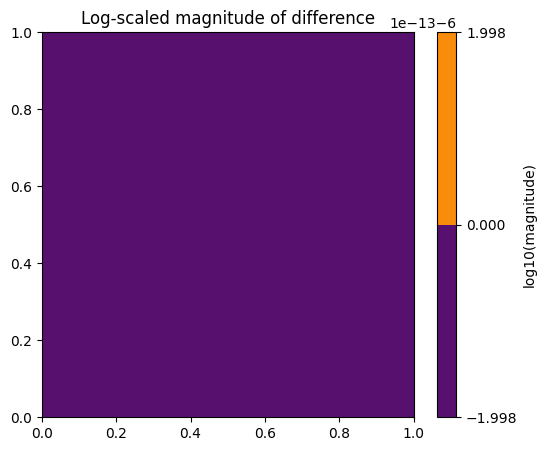

In [9]:
log_mag = np.log10(mag_dif + 1e-6)
plt.figure(figsize=(6, 5))
plt.contourf(X, Y, log_mag, cmap='inferno')
plt.colorbar(label='log10(magnitude)')
plt.title('Log-scaled magnitude of difference')
plt.show()

## 3. Difference Profile at a Vertical Cut (x ≈ 0.5)

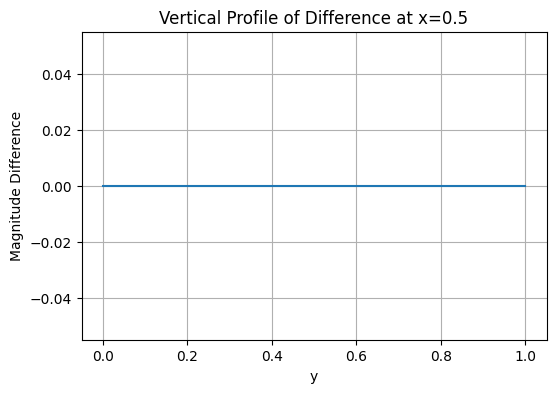

In [10]:
cut_idx = nx // 2
plt.figure(figsize=(6, 4))
plt.plot(y, mag_dif[:, cut_idx])
plt.xlabel('y')
plt.ylabel('Magnitude Difference')
plt.title('Vertical Profile of Difference at x=0.5')
plt.grid()
plt.show()

## 4. Masked Differences (Highlight Only Large Deviations)

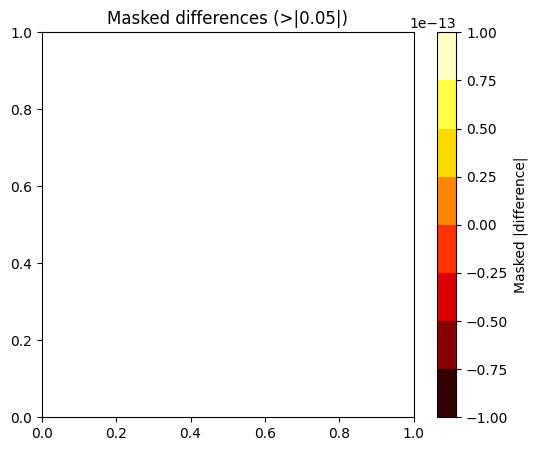

In [11]:
threshold = 0.05
masked = np.ma.masked_where(mag_dif < threshold, mag_dif)
plt.figure(figsize=(6, 5))
c = plt.contourf(X, Y, masked, cmap='hot')
plt.colorbar(label='Masked |difference|')
plt.title('Masked differences (>|0.05|)')
plt.show()